In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.neighbors import KNeighborsRegressor

import tensorflow as tf
from tensorflow.keras import layers, models

In [346]:
ts_orig = pd.read_csv(    r"C:\Users\kiril\OneDrive\Рабочий стол\jupyter_projects\btcusd_1-min_data.csv")

ts_orig['datetime'] = pd.to_datetime(ts_orig['Timestamp'], unit='s', utc=True)
ts_orig = ts_orig.set_index('datetime').sort_index()   
ts_orig = ts_orig.drop(columns=['Timestamp'])

In [347]:
ts_day = ts_orig.resample('1D').agg({
    'Open':  'first',
    'High':  'max',
    'Low':   'min',
    'Close': 'last',
    'Volume':'sum',
})
ts_day = ts_day.dropna(subset=['Open', 'Close'])

In [348]:
cutoff = ts_day.index.max() - pd.Timedelta(days=365)
ts_day = ts_day[ts_day.index >= cutoff]

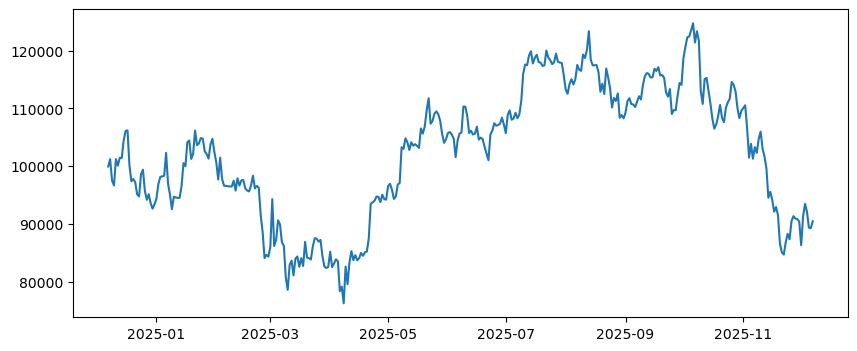

In [349]:
plt.figure(figsize=(10,4))
plt.plot(ts_day.index,ts_day['Close'])

# Добавление фичей

In [350]:

def add_features(ts_day, fourier_k=5, rsi_window=14):
    df = ts_day.copy()

    for lag in range(1, 8):
        df[f'Close_lag{lag}'] = df['Close'].shift(lag)
        df[f'Volume_lag{lag}'] = df['Volume'].shift(lag)

    df['ret'] = np.log(df['Close']).diff()

    for win in [5, 10, 20]:
        df[f'SMA_{win}']   = df['Close'].rolling(win).median()
        df[f'Vol_{win}']   = df['ret'].rolling(win).std()
        df[f'VolMA_{win}'] = df['Volume'].rolling(win).median()

    prev_close = df['Close'].shift(1)
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - prev_close).abs(),
        (df['Low']  - prev_close).abs()
    ], axis=1).max(axis=1)
    df['TR'] = tr
    df['ATR_14'] = tr.rolling(14).median()

    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(rsi_window).median()
    avg_loss = loss.rolling(rsi_window).median()
    rs = avg_gain / (avg_loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))

    ma20  = df['Close'].rolling(20).median()
    std20 = df['Close'].rolling(20).std()
    df['BB_upper'] = ma20 + 2 * std20
    df['BB_lower'] = ma20 - 2 * std20
    df['BB_pos']   = (df['Close'] - ma20) / (2 * std20 + 1e-9)

    t = np.arange(len(df))
    period = 365.0
    for k in range(1, fourier_k + 1):
        df[f'Fourier_sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        df[f'Fourier_cos_{k}'] = np.cos(2 * np.pi * k * t / period)

    df['y_close_next'] = df['Close'].shift(-1)

    df = df.dropna()
    return df


In [351]:

ts_feat = add_features(ts_day)
base_df = ts_feat[['Close']].copy()
feat_df = ts_feat.sort_index()
feat_df = feat_df.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1)


In [352]:
feat_df.head(2)

,Close_lag1,Volume_lag1,Close_lag2,Volume_lag2,Close_lag3,Volume_lag3,Close_lag4,Volume_lag4,Close_lag5,Volume_lag5,...,Fourier_cos_1,Fourier_sin_2,Fourier_cos_2,Fourier_sin_3,Fourier_cos_3,Fourier_sin_4,Fourier_cos_4,Fourier_sin_5,Fourier_cos_5,y_close_next
datetime,,,,,,,,,,,,,,,,,,,,,
2024-12-27 00:00:00+00:00,95687.0,1501.367766,99374.0,849.512248,98596.0,1444.535690,94750.0,2428.604265,95098.0,2075.508743,...,0.941317,0.635432,0.772157,0.858764,0.512371,0.981306,0.192452,0.988678,-0.150055,95139.0
2024-12-28 00:00:00+00:00,94168.0,2416.242322,95687.0,1501.367766,99374.0,849.512248,98596.0,1444.535690,94750.0,2428.604265,...,0.935368,0.661635,0.749826,0.884068,0.467359,0.992222,0.124479,0.972118,-0.234491,93557.0


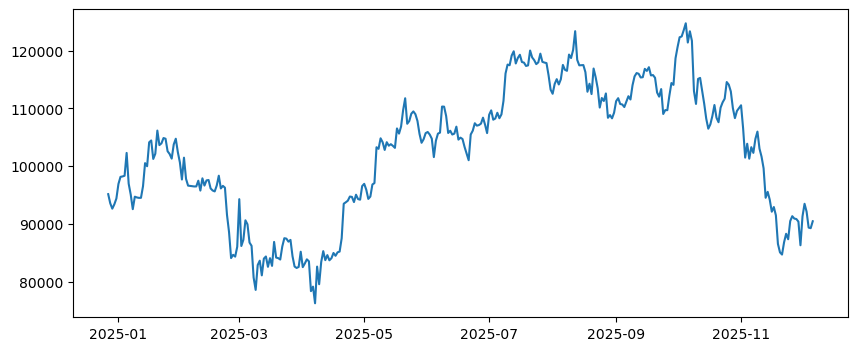

In [353]:
plt.figure(figsize=(10,4))
plt.plot(feat_df.index,feat_df['y_close_next'])

In [354]:


feature_cols = [c for c in feat_df.columns if c != 'y_close_next']
target_col   = 'y_close_next'
X_all_2d = feat_df[feature_cols].values
y_all_2d = feat_df[[target_col]].values

# ФОрмируем последовательности

In [355]:

def make_sequences(X_2d, y_2d, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X_2d)):
        X_seq.append(X_2d[i-seq_len:i])
        y_seq.append(y_2d[i])
    return np.array(X_seq), np.array(y_seq)

seq_len = 7
X_all, y_all = make_sequences(X_all_2d, y_all_2d, seq_len)

test_days  = 28
indices    = feat_df.index[seq_len:]
dates_all  = indices
dates_test = dates_all[-test_days:]
train_len  = len(indices) - test_days

X_train = X_all[:train_len]
y_train = y_all[:train_len].ravel()
X_test  = X_all[train_len:]
y_test  = y_all[train_len:].ravel()


In [356]:
close_train = base_df.loc[dates_all[:train_len], 'Close'].values
trend = pd.Series(close_train).rolling(10, min_periods=1).median().values
noise = close_train - trend

vol_factor = 3       
close_train_aug = trend + vol_factor * noise

y_train_vol = close_train_aug

vol_cols = [i for i, c in enumerate(feature_cols) if c.startswith('Vol_') or c.startswith('ATR_')]
X_train_vol = X_train.copy()
X_train_vol[..., vol_cols] *= vol_factor

X_train_final = np.concatenate([X_train, X_train_vol], axis=0)
y_train_final = np.concatenate([y_train, y_train_vol], axis=0)


# NBeats

In [357]:


backcast_length = X_train_final.shape[1]
input_dim       = X_train_final.shape[2]
forecast_length = 1

class NBeatsBlock(layers.Layer):
    def __init__(self, width=256, depth=4,
                 backcast_length=60, forecast_length=1, **kwargs):
        super().__init__(**kwargs)
        self.width = width
        self.depth = depth
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        self.fc = [layers.Dense(width, activation='relu')
                   for _ in range(depth)]
        self.backcast_fc = layers.Dense(backcast_length * input_dim)
        self.forecast_fc = layers.Dense(forecast_length)

    def call(self, x):
        h = x
        for fc in self.fc:
            h = fc(h)
        backcast = self.backcast_fc(h)
        forecast = self.forecast_fc(h)
        backcast = tf.reshape(backcast,
                              (-1, self.backcast_length, input_dim))
        return backcast, forecast

def build_nbeats(backcast_length, input_dim,
                 forecast_length=1, n_blocks=4,
                 width=256, depth=4, lr=1e-3):
    inp = layers.Input(shape=(backcast_length, input_dim))

    backcast = inp
    forecast_total = 0

    for _ in range(n_blocks):
        b = NBeatsBlock(width=width, depth=depth,
                        backcast_length=backcast_length,
                        forecast_length=forecast_length)
        backcast_res, forecast = b(layers.Flatten()(backcast))
        backcast = backcast - backcast_res
        forecast_total = forecast_total + forecast

    out = layers.Dense(1)(forecast_total)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['mae']
    )
    return model

nbeats_model = build_nbeats(
    backcast_length=backcast_length,
    input_dim=input_dim,
    forecast_length=forecast_length,
    n_blocks=4,
    width=256,
    depth=6,
    lr=1e-3
)

early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True)

history = nbeats_model.fit(
    X_train_final, y_train_final,
    validation_split=0.2,
    epochs=130,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/130


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\keras\src\optimizers\base_optimizer.py:857: UserWarning: Gradients do not exist for variables ['n_beats_block_43/dense_320/kernel', 'n_beats_block_43/dense_320/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 1570097920.0000 - mae: 25232.9238 - val_loss: 182215744.0000 - val_mae: 10882.1631
Epoch 2/130
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 71779624.0000 - mae: 6341.1943 - val_loss: 150749456.0000 - val_mae: 9495.5137
Epoch 3/130
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 72899288.0000 - mae: 6335.1494 - val_loss: 212949088.0000 - val_mae: 11872.9297
Epoch 4/130
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 87835616.0000 - mae: 7033.8252 - val_loss: 151372976.0000 - val_mae: 9619.8486
Epoch 5/130
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 77061144.0000 - mae: 6453.7383 - val_loss: 175011056.0000 - val_mae: 10400.1650
Epoch 6/130
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 74857976.0000 - mae: 6420.9126 - val_loss: 165545152.0000 - val_mae: 10306.5889
Epoch 7/130
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 63015228.0000 - mae: 5649.2588 - val_loss: 155478944.0000 - val_mae: 9649.3652
Epoch 8/130
16/16 ━━━━━━━━━━━━━

# XGBoost

In [358]:

X_train_last = X_train_final[:, -1, :]
X_test_last  = X_test[:, -1, :]


xgb = XGBRegressor(
    n_estimators=1200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
xgb.fit(X_train_last, y_train_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1200,
             n_jobs=None, num_parallel_tree=None, ...)

# KNN_reg

In [371]:

knn = KNeighborsRegressor(
    n_neighbors=12,      
    weights='distance',  
    metric='euclidean',
    n_jobs=-1
)

In [372]:

knn.fit(X_train_last, y_train_final)

y_pred_knn = knn.predict(X_test_last)


In [373]:
y_pred_nn  = nbeats_model.predict(X_test).ravel()
y_pred_xgb = xgb.predict(X_test_last)
y_pred_ens = 0.2 * y_pred_nn + 0.35 * y_pred_knn + 0.45 * y_pred_xgb

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


# Метрики


## Bias — среднее смещение прогноза

**Смысл.** Показывает, систематически завышает или занижает модель прогноз.[web:21][web:31]  

**Формула:**

$$
\text{Bias} = \frac{1}{n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)
$$





## MAPE — Mean Absolute Percentage Error

**Смысл.** Средняя абсолютная процентная ошибка.

**Формула:**

$$
\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

В коде:


## WMAPE — Weighted MAPE (WAPE)

**Смысл.** Взвешенная средняя процентная ошибка: отношение суммы абсолютных ошибок к сумме фактических значений

**Формула:**

$$
\text{WMAPE} = 100 \cdot \frac{\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|}{\sum_{i=1}^{n} \left| y_i \right|}
$$



## MAD — Mean Absolute Deviation (в твоей реализации)


**MAD:**

$$
\text{MAD} = \frac{1}{n} \sum_{i=1}^{n} \left| \hat{y}_i - \bar{y} \right|
$$



## Tracking Signal (TS)

**Смысл.** Сравнивает накопленное смещение прогноза с типичным размером отклонений (MAD)

**Формула:**

$$
\text{TS} = \frac{\sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)}{\text{MAD}}
$$

где $\text{MAD}$ — значение по формуле выше.  



In [374]:
def compute_forecast_metrics(y_true, y_pred, name="model"):
    n = len(y_true)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)

    mad  = np.sum(np.abs(y_pred - y_true.mean())) / n

    bias = np.sum(y_pred - y_true) / n

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    tracking_signal = np.sum(y_pred - y_true) / mad if mad != 0 else np.nan

    print(f"__{name} __")
    print(f"RMSE  : {rmse:.2f}")
    print(f"MAE   : {mae:.2f}")
    print(f"MAD   : {mad:.2f}")
    print(f"Bias  : {bias:.2f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"WMAPE : {wmape:.2f}%")
    print(f"TS    : {tracking_signal:.2f}")
    print()

    return {
        "name": name,
        "rmse": rmse,
        "mae": mae,
        "mad": mad,
        "bias": bias,
        "mape": mape,
        "wmape": wmape,
        "tracking_signal": tracking_signal,
    }

metrics_knn = compute_forecast_metrics(y_test, y_pred_knn, "KNN")
metrics_xgb  = compute_forecast_metrics(y_test, y_pred_xgb, "XGBoost")
metrics_nn   = compute_forecast_metrics(y_test, y_pred_nn,  "NBeats")


__KNN __
RMSE  : 6182.80
MAE   : 5097.53
MAD   : 6680.06
Bias  : 2686.33
MAPE  : 5.52%
WMAPE : 5.54%
TS    : 11.26

__XGBoost __
RMSE  : 6398.71
MAE   : 5503.12
MAD   : 5742.89
Bias  : 4535.63
MAPE  : 6.11%
WMAPE : 5.98%
TS    : 22.11

__NBeats __
RMSE  : 5650.04
MAE   : 4721.31
MAD   : 6102.12
Bias  : 2001.78
MAPE  : 5.20%
WMAPE : 5.13%
TS    : 9.19



c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [375]:
metrics_ens  = compute_forecast_metrics(y_test, y_pred_ens, "Ensemble")



__Ensemble __
RMSE  : 5558.95
MAE   : 4389.42
MAD   : 5218.79
Bias  : 3381.60
MAPE  : 4.82%
WMAPE : 4.77%
TS    : 18.14



c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


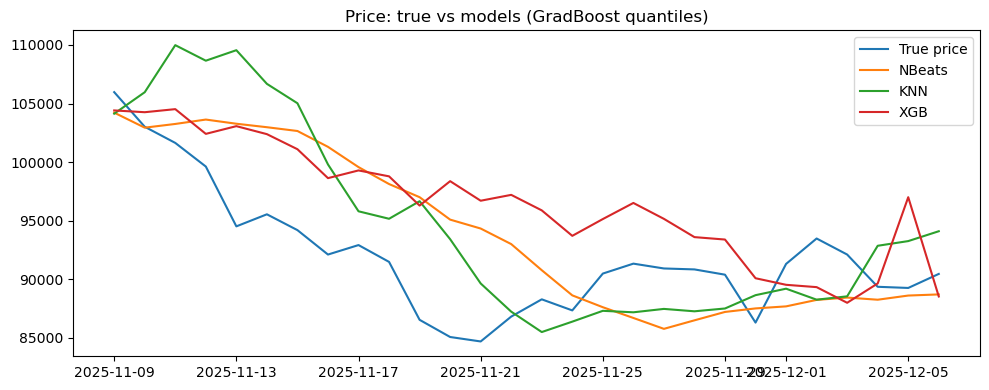

In [376]:
plt.figure(figsize=(10,4))
plt.plot(dates_test, y_test,        label='True price')
plt.plot(dates_test, y_pred_nn,     label='NBeats')
plt.plot(dates_test, y_pred_knn,    label='KNN')
plt.plot(dates_test, y_pred_xgb,    label='XGB')


plt.legend()
plt.title('Price: true vs models (GradBoost quantiles)')
plt.tight_layout()
plt.show()


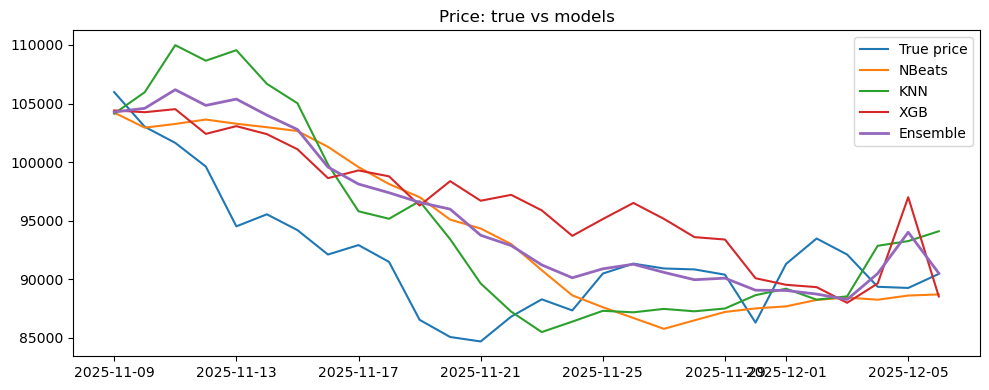

In [377]:

plt.figure(figsize=(10,4))
plt.plot(dates_test, y_test,      label='True price')
plt.plot(dates_test, y_pred_nn,   label='NBeats')
plt.plot(dates_test, y_pred_knn,   label='KNN')
plt.plot(dates_test, y_pred_xgb,  label='XGB')
plt.plot(dates_test, y_pred_ens,  label='Ensemble', linewidth=2)
plt.legend()
plt.title('Price: true vs models')
plt.tight_layout()
plt.show()


# Кастомная метрика

In [378]:

def window_confidence(y_true, y_pred, window):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    assert y_true.shape == y_pred.shape

    n = len(y_true)
    if n < window + 1:
        raise ValueError("Слишком короткий ряд для заданного окна")

    scores   = []
    shape_cs = []
    value_cs = []
    end_cs   = []

    for start in range(0, n - window + 1):
        end = start + window
        yt = y_true[start:end]
        yp = y_pred[start:end]

        # 1) Геометрия
        dyt = np.diff(yt)
        dyp = np.diff(yp)
        if dyt.std() == 0 or dyp.std() == 0:
            corr = 0.0
        else:
            corr = np.corrcoef(dyt, dyp)[0, 1]
        shape_score = max(0.0, corr)  

        # 2) Значения WMAPE внутри окна
        denom = np.sum(np.abs(yt)) + 1e-9
        wmape = np.sum(np.abs(yt - yp)) / denom  
        value_score = float(np.clip(1.0 - wmape, 0.0, 1.0))

        # 3) Итоговая точка
        if np.abs(yt[-1]) < 1e-9:
            end_err_rel = np.abs(yt[-1] - yp[-1])
        else:
            end_err_rel = np.abs(yt[-1] - yp[-1]) / np.abs(yt[-1])
        end_score = float(np.clip(1.0 - end_err_rel, 0.0, 1.0))

        conf = 0.4 * shape_score + 0.15 * value_score + 0.45 * end_score

        scores.append(conf)
        shape_cs.append(shape_score)
        value_cs.append(value_score)
        end_cs.append(end_score)

    details = {
        "shape": np.array(shape_cs),
        "value": np.array(value_cs),
        "end":   np.array(end_cs),
    }
    return np.array(scores), details


In [379]:
conf_nn, det_nn   = window_confidence(y_test, y_pred_nn,  window=7)
conf_ens, det_ens = window_confidence(y_test, y_pred_ens, window=7)
conf_knn, det_knn = window_confidence(y_test, y_pred_knn, window=7)
conf_xgb, det_xgb = window_confidence(y_test, y_pred_xgb, window=7)

print("Средняя уверенность NN  :", conf_nn.mean())
print("Средняя уверенность ENS :", conf_ens.mean())
print('Средняя уверенность XGB :',conf_xgb.mean())
print('Средняя уверенность KNN:',conf_knn.mean())

Средняя уверенность NN  : 0.6086470917891663
Средняя уверенность ENS : 0.6749311265215522
Средняя уверенность XGB : 0.7390677898283627
Средняя уверенность KNN: 0.5846301901859067
